# Sprint 5 - Análisis Estadístico de Datos

## Objetivos

1. Comprender los conceptos básicos de estadística descriptiva y aplicarlos en conjuntos de datos.
2. Explorar la teoría de la probabilidad mediante ejemplos prácticos.
3. Realizar pruebas de hipótesis usando Python.

---

## Esa vieja sensación familiar...

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from scipy import stats
from scipy import stats as st

## 0. ¿Y si hablamos sobre el aguacate?

In [ ]:
data = pd.read_csv('avocado.csv')

In [4]:
import pandas as pd
data = pd.read_csv('avocado.csv')
data.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [5]:
#Tipos de datos

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [ ]:
data.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [ ]:
data['type'].unique()

array(['conventional', 'organic'], dtype=object)

## 1. Estadística Descriptiva

### 1.1 Tipos de Variables

**Teoría:**
- **Cuantitativas:** Representan cantidades y se pueden medir numéricamente. Ejemplo: Precio promedio.
- **Cualitativas:** Representan categorías o atributos. Ejemplo: Tipo de aguacate ("conventional" o "organic").
- **Discretas:** Variables cuantitativas que solo toman valores enteros. Ejemplo: Año.
- **Continuas:** Variables cuantitativas que pueden tomar cualquier valor dentro de un rango. Ejemplo: Precio promedio.

**Práctica:**

In [ ]:
data['region'].unique()

array(['Albany', 'Atlanta', 'BaltimoreWashington', 'Boise', 'Boston',
       'BuffaloRochester', 'California', 'Charlotte', 'Chicago',
       'CincinnatiDayton', 'Columbus', 'DallasFtWorth', 'Denver',
       'Detroit', 'GrandRapids', 'GreatLakes', 'HarrisburgScranton',
       'HartfordSpringfield', 'Houston', 'Indianapolis', 'Jacksonville',
       'LasVegas', 'LosAngeles', 'Louisville', 'MiamiFtLauderdale',
       'Midsouth', 'Nashville', 'NewOrleansMobile', 'NewYork',
       'Northeast', 'NorthernNewEngland', 'Orlando', 'Philadelphia',
       'PhoenixTucson', 'Pittsburgh', 'Plains', 'Portland',
       'RaleighGreensboro', 'RichmondNorfolk', 'Roanoke', 'Sacramento',
       'SanDiego', 'SanFrancisco', 'Seattle', 'SouthCarolina',
       'SouthCentral', 'Southeast', 'Spokane', 'StLouis', 'Syracuse',
       'Tampa', 'TotalUS', 'West', 'WestTexNewMexico'], dtype=object)

### 1.2 Histogramas de Frecuencia

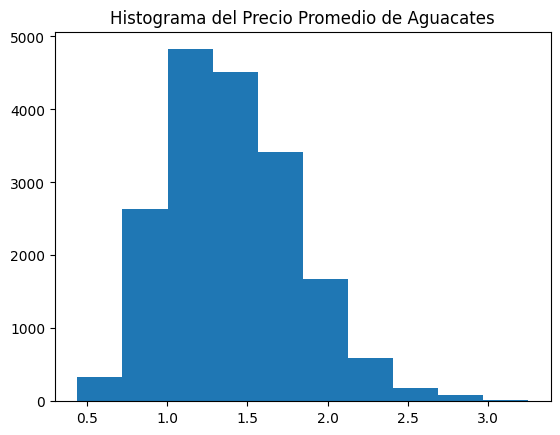

In [7]:
import matplotlib.pyplot as plt
plt.hist(data['AveragePrice'])
plt.title('Histograma del Precio Promedio de Aguacates')
plt.show()

**Teoría:**
Los histogramas muestran la distribución de una variable cuantitativa dividiendo los datos en intervalos ("bins").

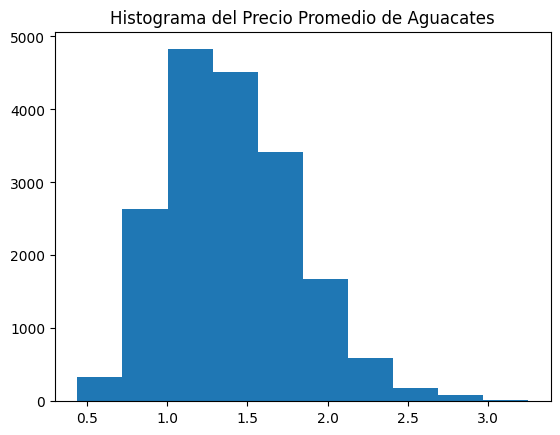

In [ ]:
# Los histogramas nos permiten entender el comportamiento de las variables cuantitativas continuas.
# La media de nuestros datos siempre se ve afectada por los valores atípicos.
# Valores atípicos son valores extremos
# Aquí vemos que los intervalos de nuestro histograma estan subdivididos por defecto en 0.25
plt.hist(data['AveragePrice'])
plt.title('Histograma del Precio Promedio de Aguacates')
plt.show()

### 1.3 Boxplots - Gráfico de Cajas y Bigotes

**Teoría:**
Un boxplot resume la distribución de los datos mediante cinco números clave: mínimo, primer cuartil, mediana, tercer cuartil y máximo. También identifica valores atípicos.



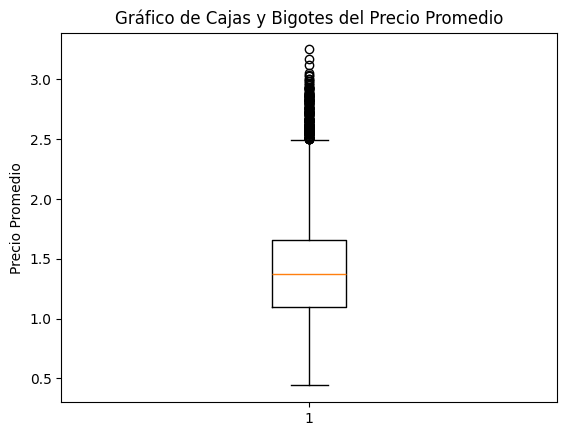

In [ ]:
plt.boxplot(data['AveragePrice'])
plt.title('Gráfico de Cajas y Bigotes del Precio Promedio')
plt.ylabel('Precio Promedio')
plt.show()

In [9]:
data.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


### 1.4 Varianza, Covarianza y Desviación Estándar


**Teoría:**
- **Varianza:** Mide cuánta variación hay en los datos.
- **Desviación estándar:** Es la raíz cuadrada de la varianza y representa la dispersión de los datos respecto a la media.
- **Covarianza:** Indica cómo dos variables cambian juntas.

In [11]:
import numpy as np
varianza = np.var(data['AveragePrice'])
desviacion_est = np.std(data['AveragePrice'])

In [ ]:
data.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [ ]:
varianza = np.var(data['AveragePrice'])
desviacion_est = np.std(data['AveragePrice'])

print(f'Varianza:{varianza}')
print(f'Desviacion Estándar:{desviacion_est}')

Varianza:0.16213952301460038
Desviacion Estándar:0.40266552250546656


In [ ]:
# Calcular la covarianza entre el precio promedio y volumen total

matriz_covarianza = np.cov(data['AveragePrice'], data['Total Volume'])
covarianza = matriz_covarianza[0][0]

In [ ]:
print(f"Covarianza: {covarianza}")

Covarianza: 0.16214840834576133


---

## 2. Teoría de la Probabilidad

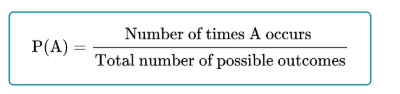

### 2.1 Predicciones Simples

### 2.2 Combinatoria y Distribución Binomial

**Teoría:**
- **Factoriales:** Utilizados para calcular combinaciones y permutaciones.
- **Combinaciones:** Número de formas de seleccionar elementos sin importar el orden.
- **Permutaciones:** Número de formas de seleccionar elementos donde el order SÍ importa.
- **Distribución binomial:** Modela la probabilidad de un número fijo de éxitos en intentos independientes.


### 2.3 Distribución Normal

**Teoría:**
La distribución normal es simétrica y se caracteriza por su media y desviación estándar. Es útil para modelar muchos fenómenos naturales.

## 3. Pruebas de Hipótesis

### 3.1 Teorema del Límite Central

**Teoría:**
El Teorema del Límite Central establece que la distribución de la media de una muestra aleatoria de datos se aproxima a una distribución normal a medida que el tamaño de la muestra aumenta.


### 3.2 Hipótesis de Dos Colas y Una Cola

**Teoría:**
Las hipótesis de dos colas evalúan si una medida es diferente de un valor específico, mientras que las de una cola evalúan si es mayor o menor.

### 3.3 Comparación de Medias

**Teoría:**
Se compara la media de dos grupos independientes o emparejados para evaluar diferencias significativas.